## Question 1

In [46]:
import numpy as np
import pandas as pd
import yfinance as yf

stocks = ["NVDA", "AAPL", "MSFT", "GOOGL", "AMZN", "AVGO", "META", "TSLA", "BRK-B", "JPM"]

start_data = '2024-08-01'
end_data = '2025-11-01'
raw_data = yf.download(stocks, start=start_data, end=end_data)
print(raw_data.head())
# print(raw_data.columns)
print(raw_data.shape)

price_data = raw_data['Close']
price_data = price_data.dropna()
print(price_data.shape)
price_data = price_data.reindex(columns=stocks)  # Ensure correct column order

print(price_data.head())

# calculate the return 𝑅𝑖(𝑡) of the stock i
log_price = np.log(price_data)
log_returns = log_price.diff().dropna()
print(f"Log Returns:")
print(log_returns.head())
print(log_returns.shape)

C:\Users\12546\AppData\Local\Temp\ipykernel_9396\1064627430.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(stocks, start=start_data, end=end_data)
[*********************100%***********************]  10 of 10 completed

Price            Close                                                  \
Ticker            AAPL        AMZN        AVGO       BRK-B       GOOGL   
Date                                                                     
2024-08-01  216.886917  184.070007  145.114807  431.809998  169.784958   
2024-08-02  218.376801  167.899994  141.956253  428.359985  165.708389   
2024-08-05  207.858231  161.020004  140.238800  413.720001  158.340683   
2024-08-06  205.831985  161.929993  142.054962  422.140015  157.386154   
2024-08-07  208.404541  162.770004  134.504074  427.019989  158.032455   

Price                                                                   ...  \
Ticker             JPM        META        MSFT        NVDA        TSLA  ...   
Date                                                                    ...   
2024-08-01  202.408600  495.706940  412.484985  109.169357  216.860001  ...   
2024-08-02  193.824036  486.146149  403.960541  107.230072  207.669998  ...   
2024-08-05  

## Question 2

In [47]:
import numpy as np  

train_end = '2025-07-31'
train_returns = log_returns.loc[:train_end]

# Compute correlation matrix (keep full precision for later use)
corr_matrix = train_returns.corr()

print(" Correlation Matrix")
with np.printoptions(precision=3, suppress=True):
    print(corr_matrix.values)

print("\n Full correlation matrix (with stock names):")
print(corr_matrix)

 Correlation Matrix
[[1.    0.442 0.625 0.5   0.581 0.681 0.561 0.458 0.19  0.416]
 [0.442 1.    0.564 0.493 0.579 0.381 0.55  0.48  0.44  0.47 ]
 [0.625 0.564 1.    0.536 0.715 0.52  0.679 0.464 0.31  0.448]
 [0.5   0.493 0.536 1.    0.647 0.463 0.535 0.521 0.224 0.4  ]
 [0.581 0.579 0.715 0.647 1.    0.553 0.738 0.531 0.355 0.558]
 [0.681 0.381 0.52  0.463 0.553 1.    0.514 0.452 0.141 0.362]
 [0.561 0.55  0.679 0.535 0.738 0.514 1.    0.482 0.266 0.468]
 [0.458 0.48  0.464 0.521 0.531 0.452 0.482 1.    0.353 0.461]
 [0.19  0.44  0.31  0.224 0.355 0.141 0.266 0.353 1.    0.644]
 [0.416 0.47  0.448 0.4   0.558 0.362 0.468 0.461 0.644 1.   ]]

 Full correlation matrix (with stock names):
Ticker      NVDA      AAPL      MSFT     GOOGL      AMZN      AVGO      META  \
Ticker                                                                         
NVDA    1.000000  0.442177  0.624663  0.499913  0.580955  0.680573  0.561024   
AAPL    0.442177  1.000000  0.563962  0.492936  0.578994  0.380

## Question 3

In [48]:
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix.values)
print("\n Eigenvalues:")
with np.printoptions(precision=3, suppress=True):
    print(eigenvalues)  
print("\n Eigenvectors:")
with np.printoptions(precision=3, suppress=True):
    print(eigenvectors)


 Eigenvalues:
[5.426 1.225 0.666 0.62  0.216 0.265 0.307 0.355 0.485 0.436]

 Eigenvectors:
[[-0.324 -0.302  0.422  0.125 -0.242  0.358 -0.473 -0.389 -0.143  0.17 ]
 [-0.315  0.172 -0.373  0.06  -0.025 -0.125 -0.18   0.265 -0.712  0.319]
 [-0.349 -0.129 -0.171  0.35   0.329 -0.401  0.237 -0.596 -0.053 -0.161]
 [-0.315 -0.141 -0.335 -0.431  0.221  0.146  0.044 -0.092  0.421  0.57 ]
 [-0.372 -0.057 -0.205  0.131 -0.786 -0.198  0.165  0.131  0.296 -0.095]
 [-0.3   -0.35   0.553 -0.027  0.159 -0.139  0.475  0.418 -0.123  0.148]
 [-0.346 -0.131 -0.258  0.282  0.301  0.521 -0.09   0.36   0.134 -0.447]
 [-0.303  0.066  0.055 -0.749 -0.029 -0.053 -0.033 -0.126 -0.205 -0.526]
 [-0.213  0.7    0.185  0.084 -0.056  0.421  0.44  -0.194 -0.036  0.103]
 [-0.298  0.454  0.301  0.083  0.212 -0.405 -0.48   0.203  0.357  0.014]]


## Question 4

In [49]:
idx_ascending = np.argsort(eigenvalues)
idx_largest = idx_ascending[::-1] 

sorted_eigenvalues = eigenvalues[idx_largest]
sorted_eigenvectors = eigenvectors[:, idx_largest]

print("\n Sorted Eigenvalues:")
with np.printoptions(precision=3, suppress=True):
    print(sorted_eigenvalues)
print("\n Sorted Eigenvectors:")
with np.printoptions(precision=3, suppress=True):
    print(sorted_eigenvectors)


 Sorted Eigenvalues:
[5.426 1.225 0.666 0.62  0.485 0.436 0.355 0.307 0.265 0.216]

 Sorted Eigenvectors:
[[-0.324 -0.302  0.422  0.125 -0.143  0.17  -0.389 -0.473  0.358 -0.242]
 [-0.315  0.172 -0.373  0.06  -0.712  0.319  0.265 -0.18  -0.125 -0.025]
 [-0.349 -0.129 -0.171  0.35  -0.053 -0.161 -0.596  0.237 -0.401  0.329]
 [-0.315 -0.141 -0.335 -0.431  0.421  0.57  -0.092  0.044  0.146  0.221]
 [-0.372 -0.057 -0.205  0.131  0.296 -0.095  0.131  0.165 -0.198 -0.786]
 [-0.3   -0.35   0.553 -0.027 -0.123  0.148  0.418  0.475 -0.139  0.159]
 [-0.346 -0.131 -0.258  0.282  0.134 -0.447  0.36  -0.09   0.521  0.301]
 [-0.303  0.066  0.055 -0.749 -0.205 -0.526 -0.126 -0.033 -0.053 -0.029]
 [-0.213  0.7    0.185  0.084 -0.036  0.103 -0.194  0.44   0.421 -0.056]
 [-0.298  0.454  0.301  0.083  0.357  0.014  0.203 -0.48  -0.405  0.212]]


## Question 5

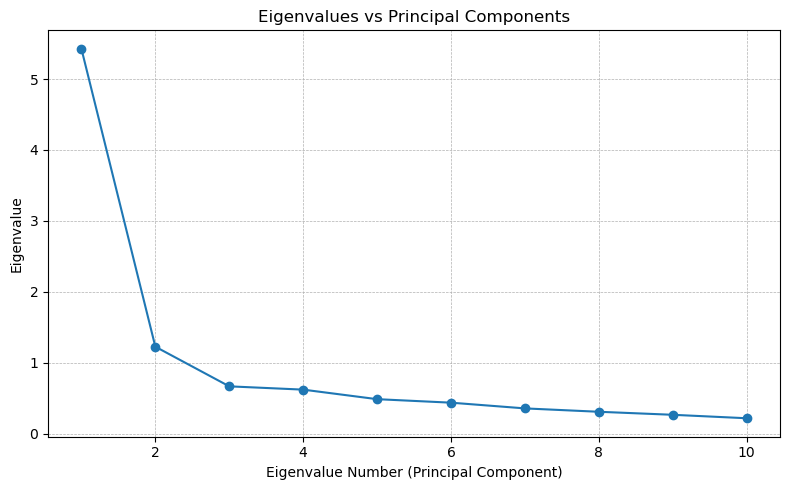

In [50]:
import matplotlib.pyplot as plt

# 碎石图
eigen_numbers = np.arange(1, len(sorted_eigenvalues) + 1)
plt.figure(figsize=(8, 5))
plt.plot(eigen_numbers, sorted_eigenvalues, marker='o')
plt.title('Eigenvalues vs Principal Components')

plt.xlabel('Eigenvalue Number (Principal Component)')
plt.ylabel('Eigenvalue')
plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## Question 6

In [51]:
total_variance = np.sum(sorted_eigenvalues)
coumsum_variance = np.cumsum(sorted_eigenvalues)
cumulative_variance_ratio = coumsum_variance / total_variance

indices_below_80 = np.where(cumulative_variance_ratio < 0.8)[0]

if len(indices_below_80) > 0:
    num_components_80 = indices_below_80[-1] + 1
else:
    num_components_80 = 0

print(" Cumulative variance ratios (rounded to 3 decimals):")
with np.printoptions(precision=3, suppress=True):
    for i, ratio in enumerate(cumulative_variance_ratio, 1):
        marker = " ← N" if i == num_components_80 else ""
        print(f"  PC{i}: {ratio:.3f}{marker}")

 Cumulative variance ratios (rounded to 3 decimals):
  PC1: 0.543
  PC2: 0.665
  PC3: 0.732
  PC4: 0.794 ← N
  PC5: 0.842
  PC6: 0.886
  PC7: 0.921
  PC8: 0.952
  PC9: 0.978
  PC10: 1.000


## Question 7

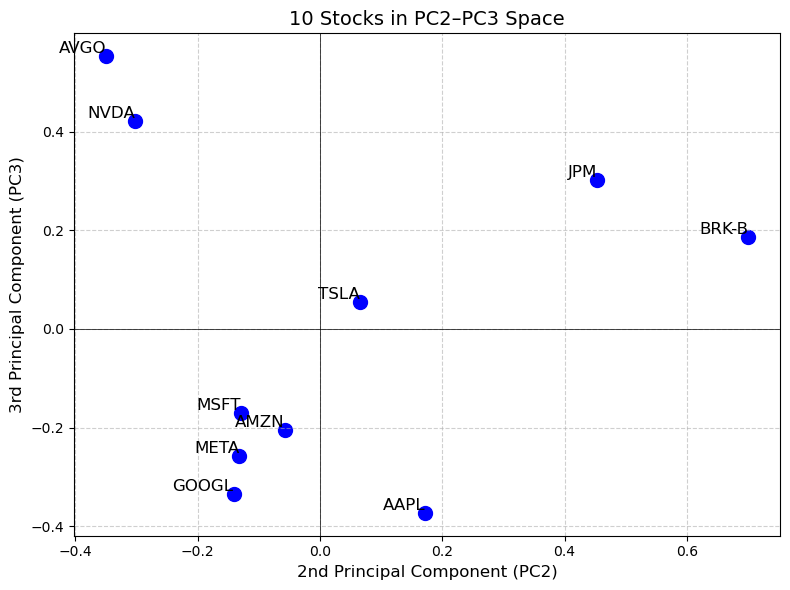

In [52]:
pc2 = sorted_eigenvectors[:, 1]  
pc3 = sorted_eigenvectors[:, 2]  
stocks = ["NVDA", "AAPL", "MSFT", "GOOGL", "AMZN", "AVGO", "META", "TSLA", "BRK-B", "JPM"]

# Plot PC2 vs PC3
plt.figure(figsize=(8, 6))
plt.scatter(pc2, pc3,s=100,color = 'blue')
for i, stock in enumerate(stocks):
    plt.text(pc2[i], pc3[i], stock, fontsize=12, ha='right', va='bottom')

plt.xlabel('2nd Principal Component (PC2)', fontsize=12)
plt.ylabel('3rd Principal Component (PC3)', fontsize=12)
plt.title('10 Stocks in PC2–PC3 Space', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


### Cluster Interpretation

From the plot of the 10 stocks in the space of the 2nd and 3rd principal components, we observe the following structure:

- **Technology stocks** (AAPL, MSFT, GOOGL, AMZN, META) form a tight cluster, indicating that their return dynamics are highly aligned along these two principal risk factors. This reflects their shared exposure to common drivers such as consumer demand, cloud computing growth, and digital advertising trends.

- **NVIDIA (NVDA)**, while also a technology company, appears slightly separated from the main tech cluster. This likely stems from its unique positioning in the semiconductor and AI hardware markets, which may respond more strongly to cyclical supply-demand imbalances or geopolitical factors affecting chip manufacturing.

- **Financial stocks** (JPM and BRK-B) are clearly separated from the technology group, often lying in opposite quadrants. This suggests that financial firms are influenced by distinct macroeconomic factors—such as interest rates, credit risk, and regulatory environments—that are orthogonal to the tech-driven risk modes captured by PC2 and PC3.

- **Tesla (TSLA) and Broadcom (AVGO)** occupy more isolated positions. TSLA’s deviation reflects its hybrid nature as both an automotive and clean-energy company with high volatility and idiosyncratic risk. AVGO, though a semiconductor firm like NVDA, shows different sensitivity—possibly due to its focus on enterprise and infrastructure chips rather than consumer GPUs.

Overall, the clustering reveals meaningful sectoral and business-model-based differentiation captured by the second and third principal components, beyond the market-wide effect (which dominates PC1).

## Question 8

 Strategy A: Equal Weight
Initial capital: 1.0
Initial shares (volume) on 2024-08-01 :
  NVDA: 0.000916
  AAPL: 0.000461
  MSFT: 0.000242
  GOOGL: 0.000589
  AMZN: 0.000543
  AVGO: 0.000689
  META: 0.000202
  TSLA: 0.000461
  BRK-B: 0.000232
  JPM: 0.000494

 Rebalancing on trading day: 2025-02-03
New shares after rebalancing:
  NVDA: 0.001081
  AAPL: 0.000556
  MSFT: 0.000309
  GOOGL: 0.000629
  AMZN: 0.000531
  AVGO: 0.000583
  META: 0.000181
  TSLA: 0.000329
  BRK-B: 0.000271
  JPM: 0.000480


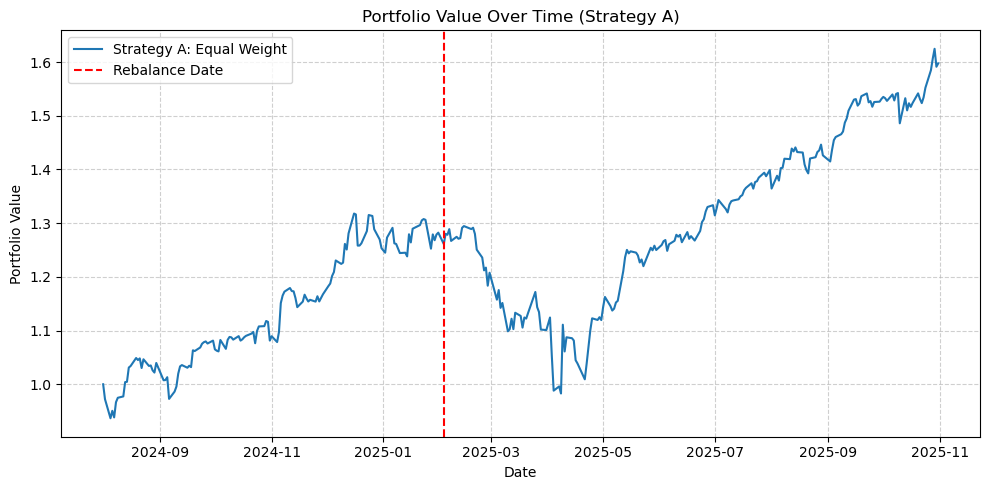

In [53]:
initial_capital = 1.0  # final results are ratios
intended_rebalance_date = "2025-02-02"

capital_per_stock = initial_capital / len(stocks)  

# First trading day
first_date = price_data.index[0]
initial_prices = price_data.loc[first_date]

# Compute initial shares (volume)
shares_a = capital_per_stock / initial_prices

print(" Strategy A: Equal Weight")
print(f"Initial capital: {initial_capital}")
print("Initial shares (volume) on", first_date.date(), ":")
for ticker, vol in zip(stocks, shares_a):
    print(f"  {ticker}: {vol:.6f}")

# Compute portfolio value over time
portfolio_value_a = pd.Series(index=price_data.index, dtype=float)

for date in price_data.index:
    portfolio_value_a[date] = (shares_a * price_data.loc[date]).sum()

# Rebalance after 2025-02-02
# Find the first trading day >= 2025-02-02
rebalance_date = price_data.index[price_data.index >= intended_rebalance_date][0]
print(f"\n Rebalancing on trading day: {rebalance_date.date()}")

# Current portfolio value before rebalancing
current_total_value = portfolio_value_a[rebalance_date]
new_capital_per_stock = current_total_value / len(stocks)

# Get prices on rebalance day
rebalance_prices = price_data.loc[rebalance_date]
new_shares_a = new_capital_per_stock / rebalance_prices

print("New shares after rebalancing:")
for ticker, vol in zip(stocks, new_shares_a):
    print(f"  {ticker}: {vol:.6f}")

# Update portfolio value from rebalance_date onward
for date in price_data.index[price_data.index >= rebalance_date]:
    portfolio_value_a[date] = (new_shares_a * price_data.loc[date]).sum()

# plot
plt.figure(figsize=(10, 5))
plt.plot(portfolio_value_a.index, portfolio_value_a.values, label='Strategy A: Equal Weight')
plt.axvline(rebalance_date, color='red', linestyle='--', label='Rebalance Date')
plt.title('Portfolio Value Over Time (Strategy A)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

strategy_a_final_value = portfolio_value_a.iloc[-1]

## Question 9

 Strategy B: Risk Parity
Historical standard deviations (for training period):
  NVDA: 17.8966
  AAPL: 15.8434
  MSFT: 36.1609
  GOOGL: 13.5034
  AMZN: 19.9834
  AVGO: 40.8075
  META: 68.2226
  TSLA: 67.4559
  BRK-B: 26.9473
  JPM: 26.6242

Weight allocation (proportional to 1/std):
  JPM: 0.139900
  JPM: 0.158031
  JPM: 0.069239
  JPM: 0.185416
  JPM: 0.125291
  JPM: 0.061355
  JPM: 0.036700
  JPM: 0.037117
  JPM: 0.092912
  JPM: 0.094040

Initial shares (volume) on 2024-08-01:
  NVDA: 0.001281
  AAPL: 0.000729
  MSFT: 0.000168
  GOOGL: 0.001092
  AMZN: 0.000681
  AVGO: 0.000423
  META: 0.000074
  TSLA: 0.000171
  BRK-B: 0.000215
  JPM: 0.000465

🔄 Rebalancing on 2025-02-03...
New shares after rebalancing:
  NVDA: 0.001433
  AAPL: 0.000832
  MSFT: 0.000203
  GOOGL: 0.001104
  AMZN: 0.000630
  AVGO: 0.000339
  META: 0.000063
  TSLA: 0.000116
  BRK-B: 0.000239
  JPM: 0.000428


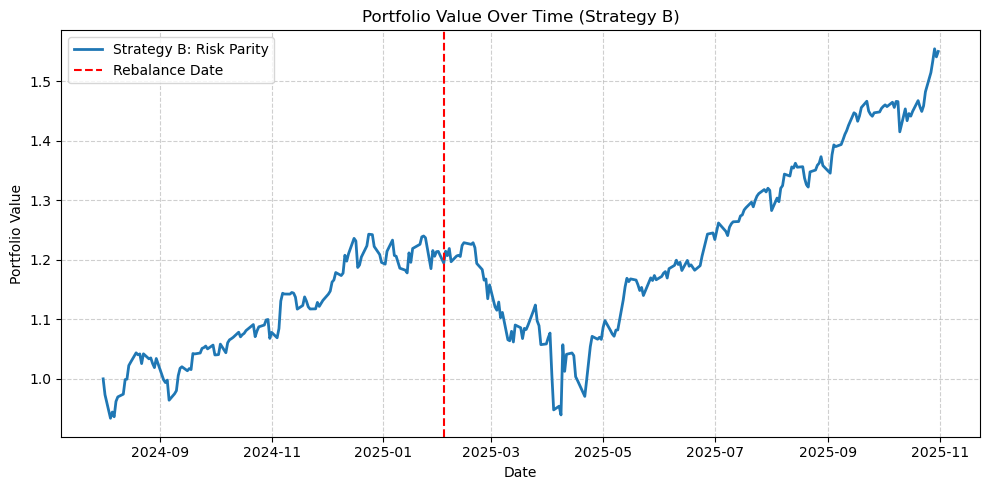

In [54]:
# Define rebalance date (first trading day >= 2025-02-02)
intended_rebalance = "2025-02-02"
rebalance_date = price_data.index[price_data.index >= intended_rebalance][0]

# Use training period: 2024-08-01 to 2025-07-31 (same as correlation matrix)
train_prices = price_data.loc[:'2025-07-31']
stock_stds = train_prices.std()  

print(" Strategy B: Risk Parity")
print("Historical standard deviations (for training period):")
for stock, std in zip(stocks, stock_stds):
    print(f"  {stock}: {std:.4f}")

# Compute weights proportional to 1 / std_i ---
# Ensures each stock has equal risk contribution
weights_b = 1.0 / stock_stds
weights_b = weights_b / weights_b.sum()  # Normalize to sum to 1

print("\nWeight allocation (proportional to 1/std):")
for stock, w in zip(stocks, weights_b):
    print(f"  {ticker}: {w:.6f}")

# Compute initial shares (volume) based on weights and first-day prices ---
initial_investment = 1.0  # We can use 1 for simplicity
first_date = price_data.index[0]
first_prices = price_data.loc[first_date]

# Capital allocated to each stock = weight * total investment
capital_per_stock_b = weights_b * initial_investment

# Shares to buy = capital / price
shares_b = capital_per_stock_b / first_prices

print(f"\nInitial shares (volume) on {first_date.date()}:")
for ticker, shares in zip(stocks, shares_b):
    print(f"  {ticker}: {shares:.6f}")

# Compute portfolio value over time ---
portfolio_value_b = pd.Series(index=price_data.index, dtype=float)

for date in price_data.index:
    current_prices = price_data.loc[date]
    portfolio_value_b[date] = (shares_b * current_prices).sum()

# Rebalance on rebalance_date ---
if rebalance_date in price_data.index:
    print(f"\n🔄 Rebalancing on {rebalance_date.date()}...")

    # Current portfolio value before rebalancing
    pre_rebalance_value = portfolio_value_b[rebalance_date]

    # New capital per stock = weight * current total value
    new_capital_per_stock_b = weights_b * pre_rebalance_value

    # Get prices on rebalance day
    rebalance_prices = price_data.loc[rebalance_date]

    # Compute NEW shares
    new_shares_b = new_capital_per_stock_b / rebalance_prices

    print("New shares after rebalancing:")
    for stock, shares in zip(stocks, new_shares_b):
        print(f"  {stock}: {shares:.6f}")

    # Update portfolio value from rebalance_date onward
    for date in price_data.index[price_data.index >= rebalance_date]:
        current_prices = price_data.loc[date]
        portfolio_value_b[date] = (new_shares_b * current_prices).sum()

# plot
plt.figure(figsize=(10, 5))
plt.plot(portfolio_value_b.index, portfolio_value_b.values, label='Strategy B: Risk Parity', linewidth=2)
plt.axvline(rebalance_date, color='red', linestyle='--', label='Rebalance Date')
plt.title('Portfolio Value Over Time (Strategy B)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

strategy_b_final_value = portfolio_value_b.iloc[-1]

## Question 10

In [55]:
equal_weight_vector = np.ones(len(stocks)) / len(stocks)
N = num_components_80

first_N_eigenvectors = sorted_eigenvectors[:, :N]  # shape: (10, N)

# Compute projection of each eigenvector onto equal-weight portfolio
# projection_a = equal_weight_vector · eigenvector_a
projections = np.dot(equal_weight_vector, first_N_eigenvectors)

print(" Strategy C: Projections of first N principal components onto equal-weight portfolio")
print("N =", N)
print("Projections (rounded to 6 decimals):")
for i, proj in enumerate(projections):
    print(f"  PC{i+1}: {proj:.6f} ({'positive' if proj > 0 else 'negative'})")


 Strategy C: Projections of first N principal components onto equal-weight portfolio
N = 4
Projections (rounded to 6 decimals):
  PC1: -0.313612 (negative)
  PC2: 0.028110 (positive)
  PC3: 0.017444 (positive)
  PC4: -0.009271 (negative)


## Question 11

In [56]:
sign_corrected_eigenvectors = np.copy(first_N_eigenvectors)  # shape: (10, N)

for i in range(N):
    if projections[i] < 0:
        print(f" Flipping sign of PC{i+1} (projection was negative)")
        sign_corrected_eigenvectors[:, i] *= -1

# Compute total weight for each stock: average of the N sign-corrected eigenvectors
total_weights_c = np.mean(sign_corrected_eigenvectors, axis=1)  # shape: (10,)

print("\n Total stock weights for Strategy C (Equal Weight Portfolio):")
for stock, w in zip(stocks, total_weights_c):
    position = "Short" if w < 0 else "Long"
    print(f"  {stock}: {w:.6f} ({position})")

# Optional: Check sum of absolute weights (not required to be 1)
print(f"\nSum of absolute weights: {np.sum(np.abs(total_weights_c)):.4f}")

 Flipping sign of PC1 (projection was negative)
 Flipping sign of PC4 (projection was negative)

 Total stock weights for Strategy C (Equal Weight Portfolio):
  NVDA: 0.079565 (Long)
  AAPL: 0.013663 (Long)
  MSFT: -0.075097 (Short)
  GOOGL: 0.067466 (Long)
  AMZN: -0.005251 (Short)
  AVGO: 0.132477 (Long)
  META: -0.081131 (Short)
  TSLA: 0.293165 (Long)
  BRK-B: 0.253614 (Long)
  JPM: 0.242622 (Long)

Sum of absolute weights: 1.2441


## Question 12

Strategy C: Short Positions
Stocks in short positions: ['MSFT', 'AMZN', 'META']

Raw initial portfolio value (before normalization): 192.366359
Normalized initial portfolio value: 1.000000 (should be 1.0)

 Rebalancing on 2025-02-03...


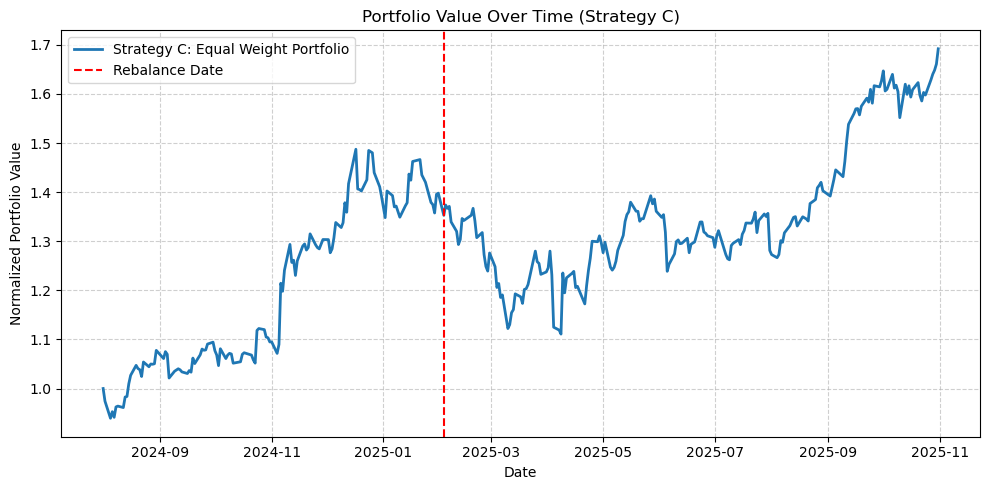

In [57]:
short_stocks = [stock for stock, w in zip(stocks, total_weights_c) if w < 0]
print("Strategy C: Short Positions")
if short_stocks:
    print("Stocks in short positions:", short_stocks)
else:
    print("No short positions.")

# Define rebalance date (first trading day >= 2025-02-02) 
intended_rebalance = "2025-02-02"
rebalance_date = price_data.index[price_data.index >= intended_rebalance][0]

# Compute initial portfolio value (before normalization)
first_date = price_data.index[0]
initial_prices = price_data.loc[first_date]
initial_value_raw = np.dot(total_weights_c, initial_prices)
print(f"\nRaw initial portfolio value (before normalization): {initial_value_raw:.6f}")

# Normalize weights so that initial value = 1
normalized_weights_c = total_weights_c / initial_value_raw
normalized_initial_value = np.dot(normalized_weights_c, initial_prices)
print(f"Normalized initial portfolio value: {normalized_initial_value:.6f} (should be 1.0)")

# Compute shares to buy (volume) based on normalized weights 
shares_c = normalized_weights_c  

# Portfolio value on day t = sum(weight_i * price_i(t))
portfolio_value_c = pd.Series(index=price_data.index, dtype=float)

for date in price_data.index:
    current_prices = price_data.loc[date]
    portfolio_value_c[date] = np.dot(normalized_weights_c, current_prices)

# Rebalance on rebalance_date 
print(f"\n Rebalancing on {rebalance_date.date()}...")
pre_rebalance_value = portfolio_value_c[rebalance_date]

# Update portfolio value from rebalance_date onward (same weights)
for date in price_data.index[price_data.index >= rebalance_date]:
    current_prices = price_data.loc[date]
    portfolio_value_c[date] = np.dot(normalized_weights_c, current_prices)

# Plot 
plt.figure(figsize=(10, 5))
plt.plot(portfolio_value_c.index, portfolio_value_c.values, label='Strategy C: Equal Weight Portfolio', linewidth=2)
plt.axvline(rebalance_date, color='red', linestyle='--', label='Rebalance Date')
plt.title('Portfolio Value Over Time (Strategy C)')
plt.xlabel('Date')
plt.ylabel('Normalized Portfolio Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Store final portfolio value for later comparison
strategy_c_final_value = portfolio_value_c.iloc[-1]

## Question 13

Strategy D: Diversified Risk Parity
N = 4
Capital allocation to each principal portfolio (proportional to 1/sqrt(λa)):
  PC1: 0.112128
  PC2: 0.235995
  PC3: 0.320053
  PC4: 0.331824

Total stock weights (before sign correction):
  NVDA: 0.068755 (Long)
  AAPL: -0.094324 (Short)
  MSFT: -0.008193 (Short)
  GOOGL: -0.318720 (Short)
  AMZN: -0.077207 (Short)
  AVGO: 0.051998 (Long)
  META: -0.058812 (Short)
  TSLA: -0.249540 (Short)
  BRK-B: 0.228476 (Long)
  JPM: 0.197329 (Long)
Flipping sign of PC1 (projection was negative)
Flipping sign of PC4 (projection was negative)

Total stock weights (after sign correction):
  NVDA: 0.058465 (Long)
  AAPL: -0.063217 (Short)
  MSFT: -0.162090 (Short)
  GOOGL: 0.037806 (Long)
  AMZN: -0.080868 (Short)
  AVGO: 0.136955 (Long)
  META: -0.168094 (Short)
  TSLA: 0.315672 (Long)
  BRK-B: 0.220480 (Long)
  JPM: 0.209470 (Long)

 Short positions in Strategy D: ['AAPL', 'MSFT', 'AMZN', 'META']

 Rebalancing on 2025-02-03...


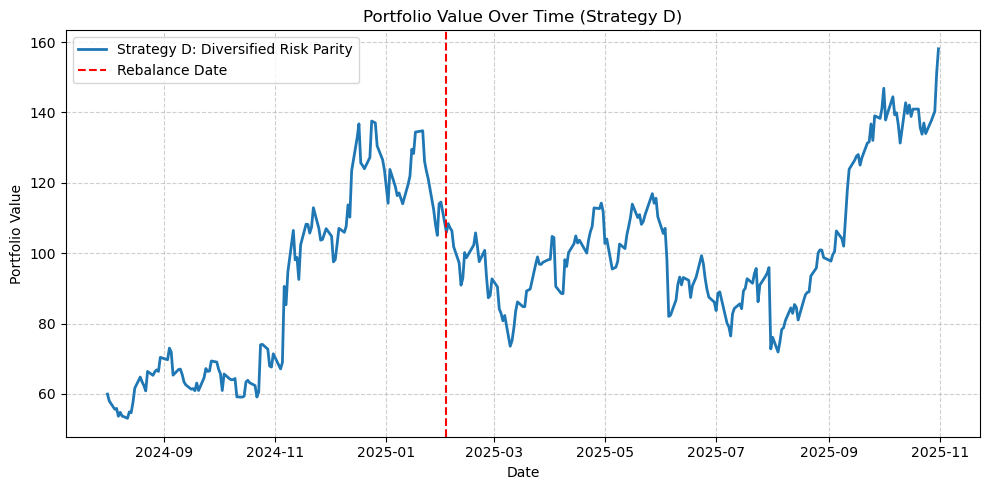

In [59]:
intended_rebalance = "2025-02-02"
rebalance_date = price_data.index[price_data.index >= intended_rebalance][0]

# sorted_eigenvalues and sorted_eigenvectors are from Step 4
first_N_eigenvalues = sorted_eigenvalues[:N]   # shape: (N,)
first_N_eigenvectors = sorted_eigenvectors[:, :N]  # shape: (10, N)

# Compute capital allocation to each principal portfolio 
# Capital proportional to 1 / sqrt(λa)
capital_allocation_per_pc = 1.0 / np.sqrt(first_N_eigenvalues)
# Normalize so sum = 1
capital_allocation_per_pc = capital_allocation_per_pc / capital_allocation_per_pc.sum()

print("Strategy D: Diversified Risk Parity")
print(f"N = {N}")
print("Capital allocation to each principal portfolio (proportional to 1/sqrt(λa)):")
for i, cap in enumerate(capital_allocation_per_pc):
    print(f"  PC{i+1}: {cap:.6f}")

# Compute total stock weights
# Each principal portfolio is represented by its eigenvector
total_weights_d = np.dot(first_N_eigenvectors, capital_allocation_per_pc)

print("\nTotal stock weights (before sign correction):")
for stock, w in zip(stocks, total_weights_d):
    position = "Short" if w < 0 else "Long"
    print(f"  {stock}: {w:.6f} ({position})")

# Sign correction 
equal_weight_vector = np.ones(len(stocks)) / len(stocks)
projections_d = np.dot(equal_weight_vector, first_N_eigenvectors)

# Apply sign correction to eigenvectors before computing weights
sign_corrected_eigenvectors_d = np.copy(first_N_eigenvectors)
for i in range(N):
    if projections_d[i] < 0:
        print(f"Flipping sign of PC{i+1} (projection was negative)")
        sign_corrected_eigenvectors_d[:, i] *= -1

# Recompute total weights with sign-corrected eigenvectors
total_weights_d_corrected = np.dot(sign_corrected_eigenvectors_d, capital_allocation_per_pc)

print("\nTotal stock weights (after sign correction):")
for stock, w in zip(stocks, total_weights_d_corrected):
    position = "Short" if w < 0 else "Long"
    print(f"  {stock}: {w:.6f} ({position})")

# Identify short positions
short_stocks_d = [stock for stock, w in zip(stocks, total_weights_d_corrected) if w < 0]
print(f"\n Short positions in Strategy D: {short_stocks_d}")

portfolio_value_d = pd.Series(index=price_data.index, dtype=float)

# Use corrected weights for value calculation
for date in price_data.index:
    current_prices = price_data.loc[date]
    portfolio_value_d[date] = np.dot(total_weights_d_corrected, current_prices)

# Rebalance on rebalance_date
print(f"\n Rebalancing on {rebalance_date.date()}...")
pre_rebalance_value = portfolio_value_d[rebalance_date]


# Update portfolio value from rebalance_date onward (same weights!)
for date in price_data.index[price_data.index >= rebalance_date]:
    current_prices = price_data.loc[date]
    portfolio_value_d[date] = np.dot(total_weights_d_corrected, current_prices)

# plot
plt.figure(figsize=(10, 5))
plt.plot(portfolio_value_d.index, portfolio_value_d.values, label='Strategy D: Diversified Risk Parity', linewidth=2)
plt.axvline(rebalance_date, color='red', linestyle='--', label='Rebalance Date')
plt.title('Portfolio Value Over Time (Strategy D)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Store final portfolio value for later comparison
strategy_d_final_value = portfolio_value_d.iloc[-1]

## Question 14

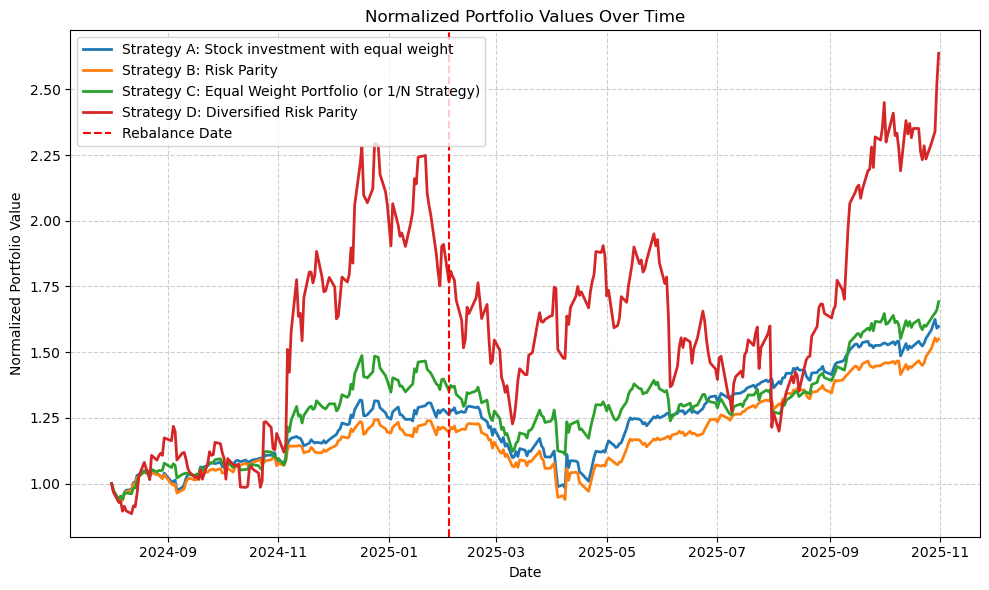

In [62]:
portfolio_value_a_norm = portfolio_value_a / portfolio_value_a.iloc[0]
portfolio_value_b_norm = portfolio_value_b / portfolio_value_b.iloc[0]
portfolio_value_c_norm = portfolio_value_c  # already normalized
portfolio_value_d_norm = portfolio_value_d / portfolio_value_d.iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(portfolio_value_a_norm.index, portfolio_value_a_norm.values, label='Strategy A: Stock investment with equal weight', linewidth=2)
plt.plot(portfolio_value_b_norm.index, portfolio_value_b_norm.values, label='Strategy B: Risk Parity', linewidth=2)
plt.plot(portfolio_value_c_norm.index, portfolio_value_c_norm.values, label='Strategy C: Equal Weight Portfolio (or 1/N Strategy)', linewidth=2)
plt.plot(portfolio_value_d_norm.index, portfolio_value_d_norm.values, label='Strategy D: Diversified Risk Parity', linewidth=2)
plt.axvline(rebalance_date, color='red', linestyle='--', label='Rebalance Date')
plt.title('Normalized Portfolio Values Over Time')      
plt.xlabel('Date')
plt.ylabel('Normalized Portfolio Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Performance Comparison of the Four Diversification Strategies

From the normalized portfolio value plot, we observe the following:

- **Strategy D (Diversified Risk Parity)** exhibits the highest volatility and the highest cumulative return. This is expected because it allocates capital to principal portfolios in proportion to $1/\sqrt{\lambda_a}$, which means it heavily weights low-variance (low-risk) components. However, since these components often capture subtle market structures (e.g., sector-specific or idiosyncratic risks), their exposure can lead to higher short-term fluctuations. The high final value suggests that this strategy successfully captured the dominant risk factors (especially PC1) while diversifying across others.

- **Strategies A, B, and C** show similar volatility profiles, with Strategy C (Equal Weight Portfolio / 1/N Strategy) slightly outperforming Strategy A (Equal Weight Stock Investment), which in turn slightly outperforms Strategy B (Risk Parity). This ranking is consistent with financial intuition:
  - Strategy C leverages PCA to construct portfolios based on the most significant risk factors, which may better capture market trends than naive equal weighting (Strategy A).
  - Strategy B, while theoretically optimal for risk diversification, underperforms here because it ignores correlations between stocks and only uses individual volatilities.

- All three strategies (A, B, C) exhibit relatively smooth trajectories compared to Strategy D, indicating lower sensitivity to short-term market noise. This is desirable for conservative investors who prioritize stability over maximum returns.


In summary, if an investor prioritizes **maximum return and can tolerate high volatility**, Strategy D is the best choice. For **balanced risk-return**, Strategy C offers the best compromise. Strategy A provides simplicity and robustness, while Strategy B, despite its theoretical appeal, underperforms in this dataset due to its neglect of cross-stock correlations.

## Question 15

In [63]:
# Helper function to compute metrics
def compute_metrics(portfolio_value):
    initial = portfolio_value.iloc[0]
    final = portfolio_value.iloc[-1]
    minimum = portfolio_value.min()
    
    # Gain = final / initial
    gain = final / initial
    
    # Daily returns (simple returns)
    daily_returns = portfolio_value.pct_change().dropna()
    
    # Standard deviation of daily returns
    std = daily_returns.std()
    
    # Min value relative to initial
    min_ratio = minimum / initial
    
    return gain, std, min_ratio

# Compute for each strategy
gain_a, std_a, min_a = compute_metrics(portfolio_value_a)
gain_b, std_b, min_b = compute_metrics(portfolio_value_b)
gain_c, std_c, min_c = compute_metrics(portfolio_value_c)
gain_d, std_d, min_d = compute_metrics(portfolio_value_d)

# Create a summary DataFrame
metrics_df = pd.DataFrame({
    "Strategy": ["A: Equal Weight", "B: Risk Parity", "C: Equal Weight Portfolio", "D: Diversified Risk Parity"],
    "Gain": [gain_a, gain_b, gain_c, gain_d],
    "Std (Daily Return)": [std_a, std_b, std_c, std_d],
    "Min / Initial": [min_a, min_b, min_c, min_d]
})

print("Performance Metrics")
print(metrics_df.round(4))

Performance Metrics
                     Strategy    Gain  Std (Daily Return)  Min / Initial
0             A: Equal Weight  1.5975              0.0170         0.9367
1              B: Risk Parity  1.5501              0.0161         0.9338
2   C: Equal Weight Portfolio  1.6920              0.0210         0.9394
3  D: Diversified Risk Parity  2.6368              0.0501         0.8855


### Risk-Return Analysis

The computed performance metrics reveal clear trade-offs among the four diversification strategies:

- **Strategy D (Diversified Risk Parity)** delivers the highest **Gain (2.637)**, significantly outperforming all others, but at the cost of much higher risk: it has the largest **daily return volatility (Std = 0.0501)** and the lowest **minimum value ratio (0.886)**, indicating a ~11.4% drawdown at its worst point. This confirms its aggressive nature, leveraging PCA-based risk allocation to capture dominant market modes at the expense of stability.

- **Strategy C (Equal Weight Portfolio)** strikes the best balance among moderate-risk strategies, achieving the second-highest gain (1.692) while maintaining a reasonable volatility (Std = 0.0210). Notably, it also has the **highest minimum value ratio (0.939)**, suggesting it offers superior downside protection compared to A and B despite higher volatility than them.

- **Strategies A (Equal Weight)** and **B (Risk Parity)** exhibit very similar risk profiles, with nearly identical minimum values (~0.934) and low volatility (~0.016–0.017). However, Strategy A slightly outperforms B in terms of final gain (1.598 vs. 1.550), implying that in this highly correlated tech-heavy universe, simple equal weighting is more effective than volatility-based risk parity—which ignores inter-stock correlations as noted in the problem statement.

In summary:
- For **maximum return** and tolerance for large swings → **Strategy D**.
- For **balanced risk-adjusted performance** → **Strategy C**.
- For **conservative, stable exposure** → **Strategy A** is preferable to B.

These findings align with both the visual trajectory in Step (14) and the theoretical properties of each strategy.

## Question 16

Out-of-Sample Performance Metrics (1 Aug 2025 – 31 Oct 2025)
                     Strategy  Gain (OOS)  Std (Daily Return, OOS)  \
0             A: Equal Weight      1.1825                   0.0116   
1              B: Risk Parity      1.1591                   0.0092   
2   C: Equal Weight Portfolio      1.3293                   0.0137   
3  D: Diversified Risk Parity      2.0776                   0.0338   

   Min / Initial (OOS)  
0                1.000  
1                1.000  
2                0.995  
3                0.945  


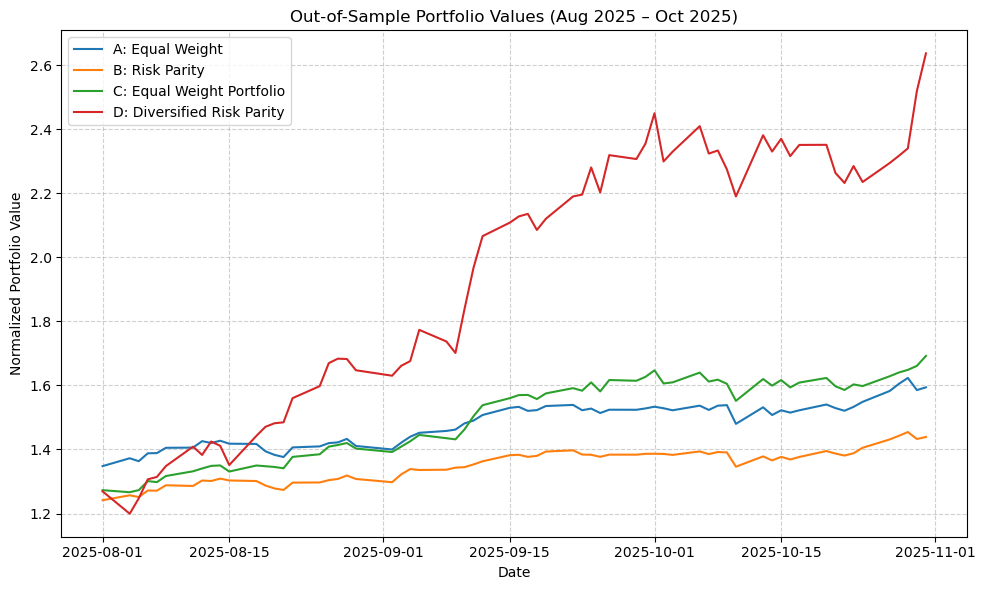

In [65]:

oos_start = "2025-08-01"
oos_end = "2025-10-31"
oos_prices = price_data.loc[oos_start:oos_end]

# Initialize portfolio value series for OOS
portfolio_value_a_oos = pd.Series(index=oos_prices.index, dtype=float)
portfolio_value_b_oos = pd.Series(index=oos_prices.index, dtype=float)
portfolio_value_c_oos = pd.Series(index=oos_prices.index, dtype=float)
portfolio_value_d_oos = pd.Series(index=oos_prices.index, dtype=float)

# Strategy A: Use initial shares_a (from in-sample) 
# shares_a was computed based on 2024-08-01 prices
for date in oos_prices.index:
    portfolio_value_a_oos[date] = (shares_a * oos_prices.loc[date]).sum()

# Strategy B: Use initial weights_b (from in-sample) 
# Re-normalize to initial investment = 1 for fair comparison
initial_value_b = (weights_b * price_data.loc[first_date]).sum()
normalized_weights_b = weights_b / initial_value_b

for date in oos_prices.index:
    portfolio_value_b_oos[date] = (normalized_weights_b * oos_prices.loc[date]).sum()

# Strategy C: Use normalized_weights_c (already normalized to 1) 
for date in oos_prices.index:
    portfolio_value_c_oos[date] = np.dot(normalized_weights_c, oos_prices.loc[date])

# Strategy D: Use total_weights_d_corrected (not normalized)
# Normalize to initial investment = 1 for fair comparison
initial_value_d = np.dot(total_weights_d_corrected, price_data.loc[first_date])
normalized_weights_d = total_weights_d_corrected / initial_value_d

for date in oos_prices.index:
    portfolio_value_d_oos[date] = np.dot(normalized_weights_d, oos_prices.loc[date])

# Compute OOS metrics 
def compute_oos_metrics(portfolio_value):
    initial = portfolio_value.iloc[0]
    final = portfolio_value.iloc[-1]
    minimum = portfolio_value.min()
    gain = final / initial
    daily_returns = portfolio_value.pct_change().dropna()
    std = daily_returns.std()
    min_ratio = minimum / initial
    return gain, std, min_ratio

gain_a_oos, std_a_oos, min_a_oos = compute_oos_metrics(portfolio_value_a_oos)
gain_b_oos, std_b_oos, min_b_oos = compute_oos_metrics(portfolio_value_b_oos)
gain_c_oos, std_c_oos, min_c_oos = compute_oos_metrics(portfolio_value_c_oos)
gain_d_oos, std_d_oos, min_d_oos = compute_oos_metrics(portfolio_value_d_oos)

# Create OOS metrics DataFrame
oos_metrics_df = pd.DataFrame({
    "Strategy": ["A: Equal Weight", "B: Risk Parity", "C: Equal Weight Portfolio", "D: Diversified Risk Parity"],
    "Gain (OOS)": [gain_a_oos, gain_b_oos, gain_c_oos, gain_d_oos],
    "Std (Daily Return, OOS)": [std_a_oos, std_b_oos, std_c_oos, std_d_oos],
    "Min / Initial (OOS)": [min_a_oos, min_b_oos, min_c_oos, min_d_oos]
})

print("Out-of-Sample Performance Metrics (1 Aug 2025 – 31 Oct 2025)")
print(oos_metrics_df.round(4))

# plot
plt.figure(figsize=(10, 6))
plt.plot(portfolio_value_a_oos.index, portfolio_value_a_oos.values, label='A: Equal Weight')
plt.plot(portfolio_value_b_oos.index, portfolio_value_b_oos.values, label='B: Risk Parity')
plt.plot(portfolio_value_c_oos.index, portfolio_value_c_oos.values, label='C: Equal Weight Portfolio')
plt.plot(portfolio_value_d_oos.index, portfolio_value_d_oos.values, label='D: Diversified Risk Parity')
plt.title('Out-of-Sample Portfolio Values (Aug 2025 – Oct 2025)')
plt.xlabel('Date')
plt.ylabel('Normalized Portfolio Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Out-of-Sample Risk-Return Analysis

The out-of-sample performance over the 3-month period (1 August – 31 October 2025) reveals consistent patterns with the in-sample results, validating the robustness of the PCA-based strategies:

- **Strategy D (Diversified Risk Parity)** again delivers the **highest gain (2.078)**—a remarkable 107.8% return in just three months—demonstrating its strong responsiveness to dominant market risk factors. However, it also exhibits the **highest volatility (Std = 0.0338)** and the **lowest minimum value ratio (0.945)**, indicating a ~5.5% intraperiod drawdown. This confirms that Strategy D, while profitable, carries significantly higher short-term risk.

- **Strategy C (Equal Weight Portfolio)** outperforms both A and B in terms of return (Gain = 1.329) and maintains **moderate volatility (Std = 0.0137)**. Notably, its minimum value is only 0.5% below the initial level, suggesting effective downside control. This highlights the advantage of PCA-based equal weighting: it captures structural market co-movements without excessive exposure to noise.

- **Strategies A (Equal Weight)** and **B (Risk Parity)** show nearly identical downside protection (Min/Initial = 1.000), but **A achieves a higher gain (1.183 vs. 1.159)** with slightly higher volatility. The underperformance of Risk Parity reinforces the limitation noted in the problem statement: by ignoring inter-stock correlations, it fails to fully exploit diversification benefits in a highly correlated tech-heavy universe.

**Conclusion**:  
Even in a short out-of-sample window, the relative ranking of strategies holds:  
- **Strategy D** is suitable for aggressive investors seeking maximum upside.  
- **Strategy C** offers the best risk-adjusted performance.  
- **Strategy A** is preferable to B for conservative investors, due to its simplicity and better returns without sacrificing stability.  

The consistency between in-sample and out-of-sample results suggests that the PCA-based strategies (C and D) are not severely overfitted and retain predictive power in the near term.